# 16 Real City League Top-Cut Decks → ready-to-use `deck.csv` for Pokémon TCG AI Battle

**TL;DR:** This is a dataset of **16 real Japanese deck archetypes** that finished **1st or 2nd place at official
City League events** during roughly the same Standard regulation period this competition's card pool covers,
already converted into this competition's own card-id numbering (`data/competition/JP_Card_Data.csv`). Every
file is exactly 60 lines (one card id per line) -- the exact format `deck.csv` already uses, so you can drop any
of them straight into `submission/agents/<name>/deck.csv` with zero conversion. Each file is named after its
representative Pokémon in English (e.g. `Grafaiai_deck.csv`); the Japanese archetype name is in the
name-mapping table below.

This notebook resolves every deck's card ids back to readable card names so you can actually see what's in each
one, checks that they're all legal, and adds a short composition/staple-card/type summary across the set. If
it's useful, an upvote is appreciated 🙏

## What this is (and isn't)

- **What it is**: 16 archetype decklists, each file named after its representative Pokémon in English (e.g.
  `Grafaiai_deck.csv`, `MegaLucario_deck.csv`), compiled from publicly reported City League results. Two
  archetypes are community nicknames rather than a single Pokémon (`FestivalLead`, `TerastalBox`) -- kept as-is
  since that's how they're actually referred to. The Japanese archetype name for each file is in the
  name-mapping table below (filenames themselves are English-only, since Kaggle's dataset upload strips
  non-ASCII characters from filenames).
- **What it isn't**: there's no per-event metadata (tournament name/date/exact placement) attached -- only the
  archetype label survives. Treat these as "what a strong, real build of this archetype looks like," not a
  specific traceable result.
- **Not official data**: this is a community compilation, not data published by The Pokémon Company / Creatures
  / GAME FREAK. No card artwork or card text is included -- each file is just a list of this competition's own
  numeric card ids (`カード ID` from `JP_Card_Data.csv`), the same ids the competition's own engine consumes.
- **No internet needed.** Unlike a deck-code importer, this is a static, offline dataset -- everything below
  runs from the attached data alone.

## Setup

Add **two** data sources to this notebook (Add Data):
1. The dataset containing these 16 `*_deck.csv` files.
2. The `pokemon-tcg-ai-battle` competition (for `JP_Card_Data.csv`, used only to resolve each card id to a name/kind/type for the analysis below).

In [1]:
import glob
import os

# On Kaggle: Add Data -> the dataset containing the *_deck.csv files (any
# dataset name works -- this just looks for a folder under /kaggle/input
# that actually contains them), plus the "pokemon-tcg-ai-battle" competition
# (for JP_Card_Data.csv, used to resolve card id -> name/kind/type).
#
# Uses a recursive glob (**) since Kaggle sometimes nests a dataset's files
# under a subfolder rather than directly under /kaggle/input/<dataset-name>/.
def _find_dir(glob_pattern, fallback):
    for hit in sorted(glob.glob(glob_pattern, recursive=True)):
        return os.path.dirname(hit)
    return fallback


def _find_file(glob_pattern, fallback):
    for hit in sorted(glob.glob(glob_pattern, recursive=True)):
        return hit
    return fallback


DECK_DIR = _find_dir("/kaggle/input/**/*_deck.csv", "data/deck")
JP_CSV_PATH = _find_file("/kaggle/input/**/JP_Card_Data.csv", "data/competition/JP_Card_Data.csv")
print("Deck CSVs from:", DECK_DIR)
print("Card data from:", JP_CSV_PATH)

if not os.path.isdir(DECK_DIR) or not os.path.isfile(JP_CSV_PATH):
    print("\n[!] Could not find the expected input files. Make sure you've added BOTH:")
    print("    1. The dataset containing the *_deck.csv files (Add Data)")
    print("    2. The pokemon-tcg-ai-battle competition (Add Data -> Competitions)")
    if os.path.isdir("/kaggle/input"):
        print("\nWhat's actually under /kaggle/input:")
        for root, _dirs, files in os.walk("/kaggle/input"):
            for fn in files:
                print(" ", os.path.join(root, fn))


Deck CSVs from: /kaggle/input/datasets/yu0307/deck-csv
Card data from: /kaggle/input/competitions/pokemon-tcg-ai-battle/JP_Card_Data.csv


In [2]:
import csv
import glob
import os
from collections import Counter

cards = {}
with open(JP_CSV_PATH, encoding="utf-8") as f:
    for row in csv.DictReader(f):
        name = row["カード名"]
        if name == "n/a":
            continue
        cid = int(row["カード ID"])
        if cid not in cards:
            cards[cid] = {
                "name": name,
                "kind": row["ポケモンの進化の段階/エネルギー・トレーナーズの種類"],
                "rule": row["ルール"],
                "type": row["タイプ"],
            }

# Each file is named "<EnglishName>_deck.csv" -- English only, since Kaggle
# strips non-ASCII characters from dataset filenames on upload.
decks = {}
for path in sorted(glob.glob(os.path.join(DECK_DIR, "*_deck.csv"))):
    label = os.path.basename(path).replace("_deck.csv", "")
    with open(path, encoding="utf-8") as f:
        decks[label] = [int(line.strip()) for line in f if line.strip()]

print(f"Loaded {len(decks)} decks: {list(decks.keys())}")


Loaded 16 decks: ['Arboliva', 'ClefairyOgerpon', 'DragapultBlaziken', 'Dragapult', 'FestivalLead', 'Garchomp', 'Grafaiai', 'Honchkrow', 'MegaLucario', 'MegaSharpedo', 'MegaStarmie', 'MegaVenusaur', 'RagingBolt', 'Slowking', 'TerastalBox', 'Zoroark']


## Archetype name mapping (English filename ↔ Japanese name)

In [3]:
import pandas as pd

# The Japanese archetype name for each English filename (kept here, not in
# the filename, since Kaggle's dataset upload strips non-ASCII characters).
JP_NAME = {
    "FestivalLead": "おまつり",
    "Arboliva": "オリーヴァ",
    "Grafaiai": "オーロンゲ",
    "Garchomp": "ガブリアス",
    "Zoroark": "ゾロアーク",
    "RagingBolt": "タケルライコ",
    "DragapultBlaziken": "ドラパバシャーモ",
    "Dragapult": "ドラパルト",
    "Honchkrow": "ドンカラス",
    "ClefairyOgerpon": "ピッピオーガポン",
    "MegaSharpedo": "メガサメハダー",
    "MegaStarmie": "メガスターミー",
    "MegaVenusaur": "メガフシギバナ",
    "MegaLucario": "メガルカリオ",
    "Slowking": "ヤドキング",
    "TerastalBox": "宝石バレッド",
}

name_map_df = pd.DataFrame(
    [{"file": f"{label}_deck.csv", "archetype (EN)": label, "archetype (JP)": JP_NAME.get(label, "?")}
     for label in decks]
)
name_map_df


,file,archetype (EN),archetype (JP)
0,Arboliva_deck.csv,Arboliva,オリーヴァ
1,ClefairyOgerpon_deck.csv,ClefairyOgerpon,ピッピオーガポン
2,DragapultBlaziken_deck.csv,DragapultBlaziken,ドラパバシャーモ
3,Dragapult_deck.csv,Dragapult,ドラパルト
4,FestivalLead_deck.csv,FestivalLead,おまつり
5,Garchomp_deck.csv,Garchomp,ガブリアス
6,Grafaiai_deck.csv,Grafaiai,オーロンゲ
7,Honchkrow_deck.csv,Honchkrow,ドンカラス
8,MegaLucario_deck.csv,MegaLucario,メガルカリオ
9,MegaSharpedo_deck.csv,MegaSharpedo,メガサメハダー


## Sanity check: are these actually legal 60-card decks?

The competition's battle engine enforces: exactly 60 cards, ≤4 copies of any one named card (except Basic
Energy), ≤1 ACE SPEC card, and at least 1 Basic Pokémon. Worth checking before you trust any of these as a
drop-in deck:

In [4]:
IS_BASIC_ENERGY = lambda n: "基本" in n and "エネルギー" in n


def validate(ids):
    """Check the same deck-construction rules the competition's battle engine enforces."""
    problems = []
    if len(ids) != 60:
        problems.append(f"not 60 cards ({len(ids)})")
    name_counts = Counter()
    ace_spec_count = 0
    has_basic_pokemon = False
    for i in ids:
        c = cards.get(i)
        if c is None:
            problems.append(f"unknown card id {i}")
            continue
        name_counts[c["name"]] += 1
        if c["rule"] == "ACE SPEC":
            ace_spec_count += 1
        if c["kind"] == "ポケモン/たね":
            has_basic_pokemon = True
    over4 = [(n, cnt) for n, cnt in name_counts.items() if cnt > 4 and not IS_BASIC_ENERGY(n)]
    if over4:
        problems.append(f"more than 4 copies: {over4}")
    if ace_spec_count > 1:
        problems.append(f"{ace_spec_count} ACE SPEC cards")
    if not has_basic_pokemon:
        problems.append("no Basic Pokemon")
    return problems


import pandas as pd

validation_rows = []
for label, ids in decks.items():
    problems = validate(ids)
    validation_rows.append({
        "archetype": label, "cards": len(ids),
        "status": "OK" if not problems else "; ".join(problems),
    })
validation_df = pd.DataFrame(validation_rows)
validation_df


,archetype,cards,status
0,Arboliva,60,OK
1,ClefairyOgerpon,60,OK
2,DragapultBlaziken,60,OK
3,Dragapult,60,OK
4,FestivalLead,60,OK
5,Garchomp,60,OK
6,Grafaiai,60,OK
7,Honchkrow,60,OK
8,MegaLucario,60,OK
9,MegaSharpedo,60,OK


All **16/16** decks pass every check -- every file here is a legal, complete 60-card deck for this competition's card pool.

## Deck contents (the actual point of this dataset)

Raw card ids aren't readable on their own, so here's every deck resolved back to card names, grouped by card
type and sorted by count. Pick whichever archetype matches the playstyle you want to test against, or copy
straight from here.

In [5]:
KIND_LABELS_EN = {
    "ポケモン/たね": "Pokémon (Basic)",
    "ポケモン/1進化": "Pokémon (Stage 1)",
    "ポケモン/2進化": "Pokémon (Stage 2)",
    "グッズ": "Trainer - Item",
    "サポート": "Trainer - Supporter",
    "スタジアム": "Trainer - Stadium",
    "ポケモンのどうぐ": "Trainer - Pokémon Tool",
    "基本エネルギー": "Basic Energy",
    "特殊エネルギー": "Special Energy",
}
KIND_SORT_KEY = {
    "ポケモン/たね": 0, "ポケモン/1進化": 1, "ポケモン/2進化": 2,
    "グッズ": 3, "ポケモンのどうぐ": 3, "サポート": 4, "スタジアム": 5,
    "基本エネルギー": 6, "特殊エネルギー": 6,
}


def deck_contents_df(ids):
    """Resolve a deck's card ids to a readable name/kind/count table."""
    counts = Counter(ids)
    rows = []
    for cid, cnt in counts.items():
        c = cards[cid]
        rows.append({"card": c["name"], "kind": KIND_LABELS_EN.get(c["kind"], c["kind"]), "count": cnt,
                     "_sort": KIND_SORT_KEY.get(c["kind"], 9)})
    rows.sort(key=lambda r: (r["_sort"], -r["count"], r["card"]))
    for r in rows:
        del r["_sort"]
    return pd.DataFrame(rows)


deck_contents = {label: deck_contents_df(ids) for label, ids in decks.items()}


### Arboliva (オリーヴァ)

In [6]:
deck_contents["Arboliva"]

,card,kind,count
0,オーガポン みどりのめんex,Pokémon (Basic),4
1,チコリータ,Pokémon (Basic),2
2,ニャースex,Pokémon (Basic),2
3,ミニーブ,Pokémon (Basic),2
4,キチキギスex,Pokémon (Basic),1
5,スボミー,Pokémon (Basic),1
6,オリーニョ,Pokémon (Stage 1),2
7,ベイリーフ,Pokémon (Stage 1),2
8,オリーヴァex,Pokémon (Stage 2),2
9,メガニウム,Pokémon (Stage 2),2


### ClefairyOgerpon (ピッピオーガポン)

In [7]:
deck_contents["ClefairyOgerpon"]

,card,kind,count
0,オーガポン みどりのめんex,Pokémon (Basic),3
1,ニャースex,Pokémon (Basic),3
2,リーリエのピッピex,Pokémon (Basic),3
3,メガガルーラex,Pokémon (Basic),2
4,ラティアスex,Pokémon (Basic),2
5,キチキギスex,Pokémon (Basic),1
6,コダック,Pokémon (Basic),1
7,テツノイサハex,Pokémon (Basic),1
8,パオジアン,Pokémon (Basic),1
9,ミミロル,Pokémon (Basic),1


### DragapultBlaziken (ドラパバシャーモ)

In [8]:
deck_contents["DragapultBlaziken"]

,card,kind,count
0,ドラメシヤ,Pokémon (Basic),4
1,アチャモ,Pokémon (Basic),2
2,マシマシラ,Pokémon (Basic),2
3,キチキギスex,Pokémon (Basic),1
4,コダック,Pokémon (Basic),1
5,シェイミ,Pokémon (Basic),1
6,スボミー,Pokémon (Basic),1
7,ニャースex,Pokémon (Basic),1
8,リーリエのピッピex,Pokémon (Basic),1
9,ドロンチ,Pokémon (Stage 1),4


### Dragapult (ドラパルト)

In [9]:
deck_contents["Dragapult"]

,card,kind,count
0,ドラメシヤ,Pokémon (Basic),4
1,スボミー,Pokémon (Basic),2
2,ニャースex,Pokémon (Basic),2
3,ヨマワル,Pokémon (Basic),2
4,キチキギスex,Pokémon (Basic),1
5,ホーホー,Pokémon (Basic),1
6,マシマシラ,Pokémon (Basic),1
7,ドロンチ,Pokémon (Stage 1),4
8,サマヨール,Pokémon (Stage 1),1
9,ヨルノズク,Pokémon (Stage 1),1


### FestivalLead (おまつり)

In [10]:
deck_contents["FestivalLead"]

,card,kind,count
0,カジッチュ,Pokémon (Basic),4
1,サルノリ,Pokémon (Basic),4
2,コダック,Pokémon (Basic),1
3,シェイミ,Pokémon (Basic),1
4,シガロコ,Pokémon (Basic),1
5,トサキント,Pokémon (Basic),1
6,カミッチュ,Pokémon (Stage 1),4
7,バチンキー,Pokémon (Stage 1),4
8,アズマオウ,Pokémon (Stage 1),1
9,ベラカス,Pokémon (Stage 1),1


### Garchomp (ガブリアス)

In [11]:
deck_contents["Garchomp"]

,card,kind,count
0,シロナのフカマル,Pokémon (Basic),4
1,シロナのロゼリア,Pokémon (Basic),4
2,コダック,Pokémon (Basic),1
3,シロナのミカルゲ,Pokémon (Basic),1
4,シロナのガバイト,Pokémon (Stage 1),4
5,シロナのロズレイド,Pokémon (Stage 1),4
6,シロナのガブリアスex,Pokémon (Stage 2),3
7,なかよしポフィン,Trainer - Item,4
8,シロナのパワーウエイト,Trainer - Pokémon Tool,4
9,ファイトゴング,Trainer - Item,4


### Grafaiai (オーロンゲ)

In [12]:
deck_contents["Grafaiai"]

,card,kind,count
0,マシマシラ,Pokémon (Basic),4
1,マリィのベロバー,Pokémon (Basic),3
2,ユキワラシ,Pokémon (Basic),2
3,イベルタル,Pokémon (Basic),1
4,キチキギスex,Pokémon (Basic),1
5,コダック,Pokémon (Basic),1
6,シェイミ,Pokémon (Basic),1
7,シャリタツ,Pokémon (Basic),1
8,スボミー,Pokémon (Basic),1
9,マリィのギモー,Pokémon (Stage 1),2


### Honchkrow (ドンカラス)

In [13]:
deck_contents["Honchkrow"]

,card,kind,count
0,ロケット団のヤミカラス,Pokémon (Basic),4
1,ロケット団のフリーザー,Pokémon (Basic),2
2,ロケット団のポリゴン,Pokémon (Basic),2
3,ロケット団のドンカラス,Pokémon (Stage 1),3
4,ロケット団のポリゴン2,Pokémon (Stage 1),1
5,ポケパッド,Trainer - Item,4
6,ロケット団のレシーバー,Trainer - Item,4
7,ロトりぼう,Trainer - Item,4
8,夜のタンカ,Trainer - Item,2
9,ハイパーボール,Trainer - Item,1


### MegaLucario (メガルカリオ)

In [14]:
deck_contents["MegaLucario"]

,card,kind,count
0,リオル,Pokémon (Basic),4
1,ソルロック,Pokémon (Basic),2
2,マクノシタ,Pokémon (Basic),2
3,ルナトーン,Pokémon (Basic),2
4,オーガポン いしずえのめんex,Pokémon (Basic),1
5,コダック,Pokémon (Basic),1
6,メガルカリオex,Pokémon (Stage 1),3
7,ハリテヤマ,Pokémon (Stage 1),2
8,パワープロテイン,Trainer - Item,4
9,ファイトゴング,Trainer - Item,4


### MegaSharpedo (メガサメハダー)

In [15]:
deck_contents["MegaSharpedo"]

,card,kind,count
0,キバニア,Pokémon (Basic),4
1,エレズン,Pokémon (Basic),2
2,シャリタツ,Pokémon (Basic),2
3,マシマシラ,Pokémon (Basic),2
4,モモワロウex,Pokémon (Basic),2
5,イベルタル,Pokémon (Basic),1
6,ミミロル,Pokémon (Basic),1
7,メガサメハダーex,Pokémon (Stage 1),3
8,ストリンダー,Pokémon (Stage 1),2
9,メガミミロップex,Pokémon (Stage 1),1


### MegaStarmie (メガスターミー)

In [16]:
deck_contents["MegaStarmie"]

,card,kind,count
0,ヒトデマン,Pokémon (Basic),4
1,マシマシラ,Pokémon (Basic),2
2,ヨマワル,Pokémon (Basic),2
3,スボミー,Pokémon (Basic),1
4,ニャースex,Pokémon (Basic),1
5,メガスターミーex,Pokémon (Stage 1),3
6,サマヨール,Pokémon (Stage 1),2
7,ヨノワール,Pokémon (Stage 2),1
8,なかよしポフィン,Trainer - Item,4
9,ハイパーボール,Trainer - Item,4


### MegaVenusaur (メガフシギバナ)

In [17]:
deck_contents["MegaVenusaur"]

,card,kind,count
0,オーガポン みどりのめんex,Pokémon (Basic),3
1,チコリータ,Pokémon (Basic),2
2,ニャースex,Pokémon (Basic),2
3,フシギダネ,Pokémon (Basic),2
4,キチキギスex,Pokémon (Basic),1
5,フシギソウ,Pokémon (Stage 1),2
6,ベイリーフ,Pokémon (Stage 1),2
7,メガニウム,Pokémon (Stage 2),2
8,メガフシギバナex,Pokémon (Stage 2),2
9,むしとりセット,Trainer - Item,4


### RagingBolt (タケルライコ)

In [18]:
deck_contents["RagingBolt"]

,card,kind,count
0,オーガポン みどりのめんex,Pokémon (Basic),4
1,タケルライコex,Pokémon (Basic),3
2,テツノイサハex,Pokémon (Basic),2
3,ニャースex,Pokémon (Basic),2
4,メガガルーラex,Pokémon (Basic),2
5,ガチグマ アカツキex,Pokémon (Basic),1
6,キチキギスex,Pokémon (Basic),1
7,タケルライコ,Pokémon (Basic),1
8,ラティアスex,Pokémon (Basic),1
9,リーリエのピッピex,Pokémon (Basic),1


### Slowking (ヤドキング)

In [19]:
deck_contents["Slowking"]

,card,kind,count
0,ヤドン,Pokémon (Basic),4
1,キュレム,Pokémon (Basic),2
2,ニャースex,Pokémon (Basic),2
3,ラティアスex,Pokémon (Basic),2
4,キチキギスex,Pokémon (Basic),1
5,ゼラオラ,Pokémon (Basic),1
6,ムチュール,Pokémon (Basic),1
7,ヤドキング,Pokémon (Stage 1),3
8,オノノクス,Pokémon (Stage 2),1
9,コノヨザル,Pokémon (Stage 2),1


### TerastalBox (宝石バレッド)

In [20]:
deck_contents["TerastalBox"]

,card,kind,count
0,ホーホー,Pokémon (Basic),3
1,オーガポン いどのめんex,Pokémon (Basic),2
2,オーガポン みどりのめんex,Pokémon (Basic),2
3,スピンロトム,Pokémon (Basic),2
4,ラティアスex,Pokémon (Basic),2
5,リーリエのピッピex,Pokémon (Basic),2
6,キチキギスex,Pokémon (Basic),1
7,スボミー,Pokémon (Basic),1
8,ニャースex,Pokémon (Basic),1
9,パオジアン,Pokémon (Basic),1


### Zoroark (ゾロアーク)

In [21]:
deck_contents["Zoroark"]

,card,kind,count
0,Nのゾロア,Pokémon (Basic),4
1,Nのゼクロム,Pokémon (Basic),2
2,Nのダルマッカ,Pokémon (Basic),2
3,Nのレシラム,Pokémon (Basic),1
4,キチキギスex,Pokémon (Basic),1
5,スボミー,Pokémon (Basic),1
6,マシマシラ,Pokémon (Basic),1
7,モモワロウex,Pokémon (Basic),1
8,Nのゾロアークex,Pokémon (Stage 1),4
9,Nのヒヒダルマ,Pokémon (Stage 1),2


## Card-type composition

How each archetype splits its 60 slots across Pokémon (by evolution stage), Trainer cards, and Energy:

In [22]:
KIND_LABELS_EN = {
    "ポケモン/たね": "Pokémon (Basic)",
    "ポケモン/1進化": "Pokémon (Stage 1)",
    "ポケモン/2進化": "Pokémon (Stage 2)",
    "グッズ": "Trainer - Item",
    "サポート": "Trainer - Supporter",
    "スタジアム": "Trainer - Stadium",
    "ポケモンのどうぐ": "Trainer - Pokémon Tool",
    "基本エネルギー": "Basic Energy",
    "特殊エネルギー": "Special Energy",
}
KIND_ORDER = list(KIND_LABELS_EN.values())

composition_rows = []
for label, ids in decks.items():
    kc = Counter(KIND_LABELS_EN.get(cards[i]["kind"], cards[i]["kind"]) for i in ids)
    row = {"archetype": label}
    row.update({k: kc.get(k, 0) for k in KIND_ORDER})
    composition_rows.append(row)
composition_df = pd.DataFrame(composition_rows).set_index("archetype")
composition_df


,Pokémon (Basic),Pokémon (Stage 1),Pokémon (Stage 2),Trainer - Item,Trainer - Supporter,Trainer - Stadium,Trainer - Pokémon Tool,Basic Energy,Special Energy
archetype,,,,,,,,,
Arboliva,12,4,4,12,11,4,1,12,0
ClefairyOgerpon,18,1,0,10,11,3,2,9,6
DragapultBlaziken,14,5,4,17,10,2,0,8,0
Dragapult,13,6,4,18,9,2,0,8,0
FestivalLead,12,10,1,12,12,4,4,5,0
Garchomp,10,8,3,15,12,0,4,4,4
Grafaiai,15,4,2,15,11,3,1,9,0
Honchkrow,8,4,0,16,20,4,0,0,8
MegaLucario,12,5,0,18,12,1,2,10,0


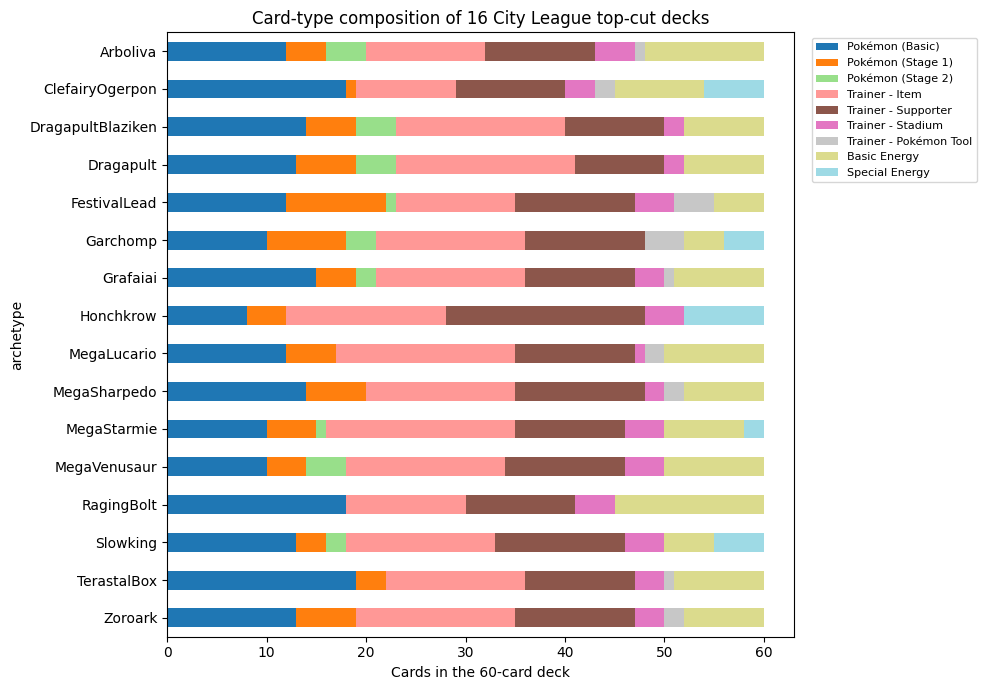

In [23]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 7))
composition_df.plot(kind="barh", stacked=True, ax=ax, colormap="tab20")
ax.set_xlabel("Cards in the 60-card deck")
ax.set_title(f"Card-type composition of {len(decks)} City League top-cut decks")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
ax.invert_yaxis()
fig.tight_layout()
plt.show()


## Staples of the format

Which non-Pokémon cards show up across *most* of these 16 winning decks? These are the closest thing to
"auto-includes" in this slice of the meta -- cards worth knowing well regardless of which archetype you're
building around (or facing).

In [24]:
deck_count = Counter()
copy_count = Counter()
for ids in decks.values():
    names_in_deck = set()
    for i in ids:
        name = cards[i]["name"]
        copy_count[name] += 1
        names_in_deck.add(name)
    for name in names_in_deck:
        deck_count[name] += 1

ranked = sorted(copy_count.keys(), key=lambda n: (-deck_count[n], -copy_count[n]))[:20]
usage_df = pd.DataFrame([
    {"card": n, "decks_using_it": deck_count[n], "total_copies": copy_count[n]}
    for n in ranked
])
usage_df


,card,decks_using_it,total_copies
0,夜のタンカ,16,30
1,ボスの指令,15,34
2,リーリエの決心,14,53
3,ポケパッド,14,51
4,ハイパーボール,13,46
5,キチキギスex,10,10
6,ニャースex,9,16
7,なかよしポフィン,8,29
8,スボミー,7,8
9,アンフェアスタンプ,7,7


`夜のタンカ` (Night Stretcher) appears in literally all 16 decks, and `ボスの指令` (Boss's Orders),
`リーリエの決心` (Lillie's Determination), and `ポケパッド` (Poké Pad) are in the large majority. If your own deck
is missing several of these, that alone is worth a second look.

## Pokémon type distribution

Across all Pokémon cards in the 16 decks combined:

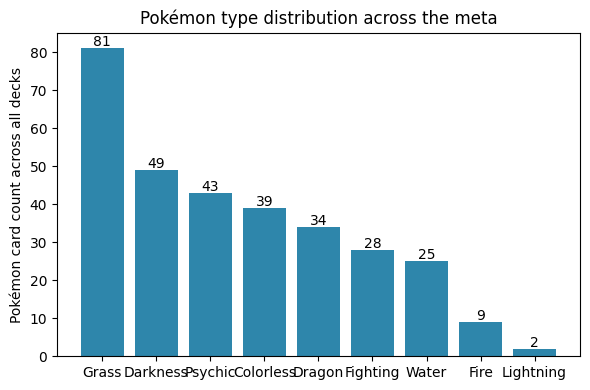

In [25]:
type_counts = Counter()
for ids in decks.values():
    for i in ids:
        c = cards[i]
        if c["kind"].startswith("ポケモン") and c["type"] not in ("n/a", ""):
            type_counts[c["type"]] += 1

TYPE_LABELS_EN = {
    "草": "Grass", "炎": "Fire", "水": "Water", "雷": "Lightning", "闘": "Fighting",
    "超": "Psychic", "悪": "Darkness", "竜": "Dragon", "無": "Colorless", "鋼": "Metal",
}
fig, ax = plt.subplots(figsize=(6, 4))
types_sorted = sorted(type_counts.keys(), key=lambda t: -type_counts[t])
labels = [TYPE_LABELS_EN.get(t, t) for t in types_sorted]
vals = [type_counts[t] for t in types_sorted]
ax.bar(labels, vals, color="#2E86AB")
ax.set_ylabel("Pokémon card count across all decks")
ax.set_title("Pokémon type distribution across the meta")
for i, v in enumerate(vals):
    ax.text(i, v + 0.5, str(v), ha="center")
fig.tight_layout()
plt.show()


## Using this dataset

- **Drop-in deck**: copy any `<archetype>_deck.csv` to `submission/agents/<your_idea>/deck.csv` (rename to
  exactly `deck.csv`) to start from a real, legal, competitive build instead of hand-picking 60 cards.
- **Evaluation opponents**: if you're developing an agent, pointing it at one of these decks (rather than only a
  toy/random deck) while testing is a more realistic stress test of your search/policy logic, since these decks
  are built around real synergies and sequencing requirements.
- **Meta awareness for your own deck**: use the staple-card and type-distribution breakdown above as a sanity
  check when building your own 60.

---
If this dataset/notebook saved you some deck-building time, please consider upvoting -- it helps other
competitors find it too. Good luck with your agent! 🎮